# ML Pipeline — Batch Forecasting & Anomaly Detection

**Interactive notebook for testing ML models without affecting BI cache tables.**

Run cells sequentially to:
1. Load/generate data
2. Backtest models (holdout evaluation)
3. Train on full data
4. Forecast next N days
5. Detect anomalies
6. Visualize results

**Note**: Results saved to JSON, NOT written to PostgreSQL cache.

---


File này thuộc **cụm ML** của kiến trúc Lambda (batch layer), gồm 2 bài toán:
- **Cụm 1 — Dự đoán xu hướng (trend forecasting)**: 2 model chạy song song trên cùng dữ liệu doanh thu theo ngày (`cache.daily_revenue`) — **N-BEATS** và **LSTM** (một dạng mạng RNN) — rồi so sánh kết quả bằng các chỉ số sai số.
- **Cụm 2 — Phát hiện bất thường (anomaly detection)**: 1 model duy nhất — **PyOD AutoEncoder** — tìm các ngày có hồ sơ doanh thu/số đơn hàng khác biệt bất thường so với phần còn lại.

**Lưu ý quan trọng**: các cell phải chạy **tuần tự đúng thứ tự**, không nhảy cóc — cell sau dùng biến do cell trước tạo ra (`daily`, `predictor`, `predictions`, `detector`, `scored`...). Cell cuối cùng (Cell 10) là cell duy nhất **ghi dữ liệu thật vào Postgres** để Superset hiển thị; các cell còn lại chỉ tính toán và lưu tạm ra file JSON.

## Cell 1: Setup & Imports

 Cell này chuẩn bị môi trường chạy — tìm đúng thư mục gốc dự án (để `import batch_layer...` không bị lỗi dù mở notebook từ đâu), bật chế độ vẽ biểu đồ trong notebook, và nạp các module ML tự viết (`TrendPredictor` cho cụm dự đoán, `AnomalyDetectorAutoEncoder` cho cụm phát hiện bất thường).

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

# Dò lên tới thư mục chứa "batch_layer" để import không phụ thuộc cwd
_root = Path.cwd()
while not (_root / 'batch_layer').exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

get_ipython().run_line_magic('matplotlib', 'inline')  # hiển thị biểu đồ trong notebook

# Core
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
import json

# ML modules -- 2 module cốt lõi của 2 cụm bài toán
from batch_layer.analytics.trend_predictor import TrendPredictor           # cụm 1: dự đoán xu hướng
from batch_layer.analytics.anomaly_detector import AnomalyDetectorAutoEncoder  # cụm 2: phát hiện bất thường

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("[OK] All imports successful")
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}, NumPy: {np.__version__}")

[OK] All imports successful
Python version: 3.11.9
Pandas: 2.3.3, NumPy: 2.4.6


## Cell 2: Configuration Parameters

**Modify these before running the pipeline:**

 Các tham số điều khiển toàn bộ pipeline. Xem chú thích tiếng Việt trong từng dòng ở cell code bên dưới.

In [2]:
# ========== CONFIGURATION ==========

# Data source
USE_SAMPLE_DATA = False  # False = đọc dữ liệu THẬT từ cache.daily_revenue (do batch job Spark ghi ra); True = dùng dữ liệu giả lập để test nhanh không cần Postgres
SAMPLE_DAYS = 45        # Số ngày dữ liệu giả lập sẽ sinh ra (chỉ dùng khi USE_SAMPLE_DATA=True)

# ML parameters
FORECAST_HORIZON = 7    # Dự báo bao nhiêu ngày TỚI (sau ngày cuối cùng có dữ liệu thật)
BACKTEST_HOLDOUT = None # Số ngày "giữ lại để kiểm tra" (test) trong MỖI fold backtest; None = tự tính = min(7, max(2, số_ngày//5))
N_SPLITS = 3            # Số fold của rolling backtest (walk-forward) -- xem giải thích chi tiết ở Cell 4; tự động giảm nếu dữ liệu không đủ dài
N_EPOCHS = 50           # Số vòng lặp huấn luyện (epoch) cho 2 model Darts (nbeats/lstm) -- epoch càng nhiều học càng kỹ nhưng cũng dễ overfit nếu ít dữ liệu

# Anomaly detection
CONTAMINATION = 0.05    # Tỷ lệ "bất thường" kỳ vọng (5%) -- PyOD dùng số này để chọn ngưỡng điểm bất thường (anomaly_score) sẽ gắn nhãn "bất thường"
N_STABILITY_RUNS = 5    # Số lần chạy lại AutoEncoder với random_state khác nhau để đánh giá độ ổn định (flag_rate) -- xem Cell 7

# Output
SAVE_JSON = True                                    # Có lưu toàn bộ kết quả ra file JSON hay không
OUTPUT_FILE = "data/logs/ml_notebook_results.json"  # Đường dẫn file JSON kết quả (chỉ để xem lại/log, KHÔNG phải nơi Superset đọc dữ liệu)
PLOT_RESULTS = True                                 # Có vẽ 4 biểu đồ ở Cell 8 hay không

print("[CONFIG]")
print(f"  Source: {'Sample data' if USE_SAMPLE_DATA else 'PostgreSQL cache'}")
if USE_SAMPLE_DATA:
    print(f"  Sample days: {SAMPLE_DAYS}")
print(f"  Forecast horizon: {FORECAST_HORIZON} days")
print(f"  Backtest folds requested: {N_SPLITS} (rolling/walk-forward)")
print(f"  Training epochs: {N_EPOCHS}")
print(f"  Anomaly contamination: {CONTAMINATION*100:.1f}%")
print(f"  Anomaly stability runs: {N_STABILITY_RUNS}")

[CONFIG]
  Source: PostgreSQL cache
  Forecast horizon: 7 days
  Backtest folds requested: 3 (rolling/walk-forward)
  Training epochs: 50
  Anomaly contamination: 5.0%
  Anomaly stability runs: 5


## Cell 3: Load / Generate Data

 Nạp dữ liệu doanh thu theo ngày (`date, revenue, purchase_events, avg_purchase_value`) — hoặc từ bảng thật `cache.daily_revenue` (Postgres, do batch job Spark ghi ra sau khi xử lý dữ liệu Kaggle), hoặc dữ liệu giả lập nếu `USE_SAMPLE_DATA=True`. Đây là dữ liệu **đầu vào duy nhất** cho cả 2 cụm ML bên dưới.

In [3]:
if USE_SAMPLE_DATA:
    # Dữ liệu giả lập: trend tăng dần + seasonality tuần + nhiễu + 1 spike bất thường
    print(f"[1] Generating {SAMPLE_DAYS} days of sample data...")
    
    dates = pd.date_range(end=datetime.now(timezone.utc), periods=SAMPLE_DAYS, freq='D')
    trend = np.linspace(10000, 15000, SAMPLE_DAYS)
    seasonality = 1500 * np.sin(2 * np.pi * np.arange(SAMPLE_DAYS) / 7)
    noise = np.random.normal(0, 500, SAMPLE_DAYS)
    anomaly_spike = np.zeros(SAMPLE_DAYS)
    anomaly_spike[20] = 5000
    
    revenue = trend + seasonality + noise + anomaly_spike
    revenue = np.maximum(revenue, 0)
    
    purchase_events = np.maximum(100 + revenue / 100 + np.random.normal(0, 10, SAMPLE_DAYS), 10).astype(int)
    avg_purchase_value = revenue / np.maximum(purchase_events, 1)
    
    daily = pd.DataFrame({
        'date': dates,
        'revenue': revenue,
        'purchase_events': purchase_events,
        'avg_purchase_value': avg_purchase_value,
    })
else:
    # Đọc dữ liệu thật từ cache.daily_revenue (Spark batch job ghi ra)
    print("[1] Reading from PostgreSQL cache.daily_revenue...")
    from batch_layer.postgres_cache import PostgresCacheSync
    cache = PostgresCacheSync()
    daily = cache.read_daily_revenue()

# Chuẩn hóa 'date' về Timestamp (Postgres trả về datetime.date thuần)
daily['date'] = pd.to_datetime(daily['date'])

print(f"    [OK] Loaded {len(daily)} days")
print(f"    Date range: {daily['date'].min().date()} to {daily['date'].max().date()}")
print(f"    Revenue: min={daily['revenue'].min():.2f}, max={daily['revenue'].max():.2f}, mean={daily['revenue'].mean():.2f}, std={daily['revenue'].std():.2f}")
print(f"    Purchase events: min={daily['purchase_events'].min()}, max={daily['purchase_events'].max()}, mean={daily['purchase_events'].mean():.1f}")

# Display head
print("\n[Data Sample]")
print(daily.head())

[1] Reading from PostgreSQL cache.daily_revenue...
    [OK] Loaded 31 days
    Date range: 2019-10-01 to 2019-10-31
    Revenue: min=31714.63, max=66879.75, mean=47607.63, std=9489.26
    Purchase events: min=103, max=210, mean=149.5

[Data Sample]
        date   revenue  purchase_events  avg_purchase_value
0 2019-10-01  49324.15              126          391.461508
1 2019-10-02  46284.16              130          356.032000
2 2019-10-03  34231.39              108          316.957315
3 2019-10-04  64589.59              190          339.945211
4 2019-10-05  44979.80              143          314.544056


## EDA — Phân tích khám phá dữ liệu (Exploratory Data Analysis)

 Trước khi đưa vào 2 cụm model, cần hiểu rõ dữ liệu `daily` đang có gì — có bị thiếu ngày không, doanh thu biến động ra sao, có khác biệt theo thứ trong tuần không, các biến có tương quan với nhau không, và có ngày nào "trông có vẻ bất thường" ngay từ góc nhìn thống kê cổ điển (trước khi chạy AutoEncoder ở Cell 7) hay không. Đây là bước luôn nên làm trước khi tin tưởng bất kỳ kết quả model nào.

In [4]:
print("="*80)
print("EDA — THỐNG KÊ MÔ TẢ & KIỂM TRA CHẤT LƯỢNG DỮ LIỆU")
print("="*80)

# [1] Thống kê mô tả cơ bản
print("\n[1] Thống kê mô tả (describe)")
print(daily[['revenue', 'purchase_events', 'avg_purchase_value']].describe().round(2).to_string())

# [2] Chất lượng dữ liệu: thiếu/trùng/hổng ngày
print(f"\n[2] Kiểm tra chất lượng dữ liệu")
print(f"    Giá trị thiếu (NaN): {int(daily[['revenue','purchase_events','avg_purchase_value']].isna().sum().sum())} ô")
print(f"    Ngày bị trùng lặp:   {int(daily['date'].duplicated().sum())}")
full_range = pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')
missing_dates = sorted(set(full_range) - set(daily['date']))
print(f"    Ngày bị thiếu trong khoảng {daily['date'].min().date()} → {daily['date'].max().date()}: {len(missing_dates)}"
      + (f" ({[d.date() for d in missing_dates]})" if missing_dates else ""))

# [3] Hệ số biến thiên (CV)
cv = daily['revenue'].std() / daily['revenue'].mean() * 100
print(f"\n[3] Hệ số biến thiên (CV) của doanh thu: {cv:.1f}%  (std/mean -- càng cao càng biến động mạnh)")

# [4] Doanh thu theo thứ trong tuần
daily['_dow'] = daily['date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_stats = daily.groupby('_dow')['revenue'].agg(['mean','count']).reindex(dow_order)
print("\n[4] Doanh thu trung bình theo thứ trong tuần (kèm số lượng mẫu)")
print(dow_stats.round(2).to_string())
print("    Lưu ý: mỗi thứ chỉ có 4-5 mẫu -- chỉ mang tính tham khảo.")

# [5] Tương quan giữa các biến
print("\n[5] Ma trận tương quan")
print(daily[['revenue','purchase_events','avg_purchase_value']].corr().round(3).to_string())

# [6] Outlier theo IQR (đối chiếu chéo với AutoEncoder ở Cell 7)
q1, q3 = daily['revenue'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
iqr_outliers = daily[(daily['revenue'] < lower) | (daily['revenue'] > upper)]
print(f"\n[6] Outlier theo IQR (ngưỡng hợp lệ: {lower:.0f} - {upper:.0f})")
print(f"    Số ngày vượt ngưỡng: {len(iqr_outliers)}")
if len(iqr_outliers) > 0:
    print(iqr_outliers[['date', 'revenue']].to_string(index=False))

daily = daily.drop(columns=['_dow'])

EDA — THỐNG KÊ MÔ TẢ & KIỂM TRA CHẤT LƯỢNG DỮ LIỆU

[1] Thống kê mô tả (describe)
        revenue  purchase_events  avg_purchase_value
count     31.00            31.00               31.00
mean   47607.63           149.55              318.09
std     9489.26            25.56               28.88
min    31714.63           103.00              247.81
25%    42244.42           131.50              305.72
50%    48070.08           150.00              314.54
75%    51145.98           163.00              335.64
max    66879.75           210.00              391.46

[2] Kiểm tra chất lượng dữ liệu
    Giá trị thiếu (NaN): 0 ô
    Ngày bị trùng lặp:   0
    Ngày bị thiếu trong khoảng 2019-10-01 → 2019-10-31: 0

[3] Hệ số biến thiên (CV) của doanh thu: 19.9%  (std/mean -- càng cao càng biến động mạnh)

[4] Doanh thu trung bình theo thứ trong tuần (kèm số lượng mẫu)
               mean  count
_dow                      
Monday     44748.93      4
Tuesday    48003.50      5
Wednesday  47408.68      5
Th

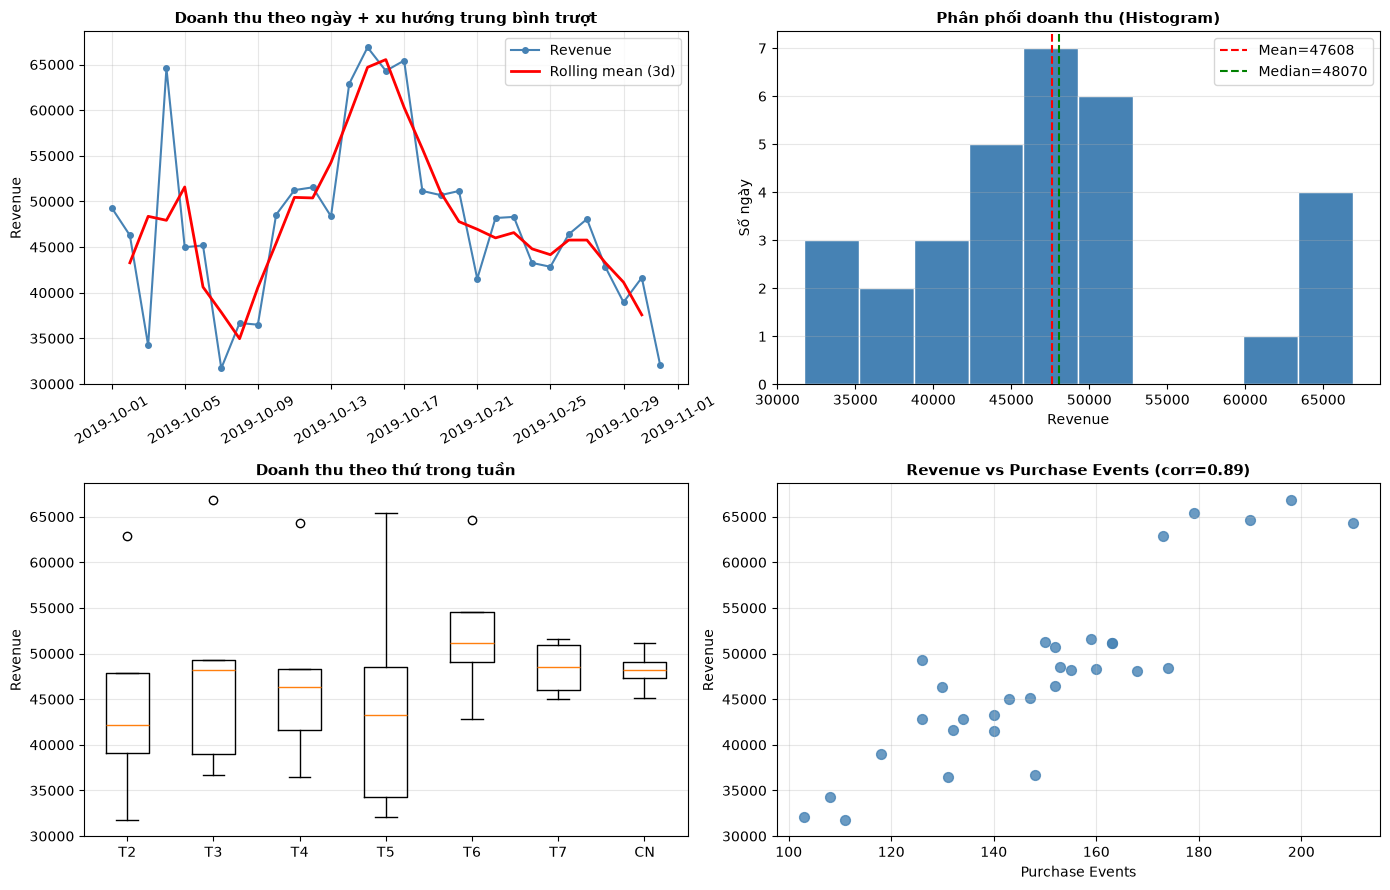

[OK] EDA plots displayed


In [5]:
# EDA — trực quan hóa: 4 biểu đồ minh họa các số liệu ở cell trên
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (1) Xu hướng doanh thu + trung bình trượt 3 ngày
ax1 = axes[0, 0]
ax1.plot(daily['date'], daily['revenue'], 'o-', color='steelblue', linewidth=1.5, markersize=4, label='Revenue')
ax1.plot(daily['date'], daily['revenue'].rolling(3, center=True).mean(), 'r-', linewidth=2, label='Rolling mean (3d)')
ax1.set_title('Doanh thu theo ngày + xu hướng trung bình trượt', fontsize=11, fontweight='bold')
ax1.set_ylabel('Revenue')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=30)

# (2) Phân phối doanh thu
ax2 = axes[0, 1]
ax2.hist(daily['revenue'], bins=10, color='steelblue', edgecolor='white')
ax2.axvline(daily['revenue'].mean(), color='red', linestyle='--', label=f"Mean={daily['revenue'].mean():.0f}")
ax2.axvline(daily['revenue'].median(), color='green', linestyle='--', label=f"Median={daily['revenue'].median():.0f}")
ax2.set_title('Phân phối doanh thu (Histogram)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Revenue')
ax2.set_ylabel('Số ngày')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# (3) Doanh thu theo thứ trong tuần
ax3 = axes[1, 0]
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_short = ['T2','T3','T4','T5','T6','T7','CN']
box_data = [daily.loc[daily['date'].dt.day_name() == d, 'revenue'].to_numpy() for d in dow_order]
ax3.boxplot(box_data, tick_labels=dow_short)
ax3.set_title('Doanh thu theo thứ trong tuần', fontsize=11, fontweight='bold')
ax3.set_ylabel('Revenue')
ax3.grid(True, alpha=0.3, axis='y')

# (4) Tương quan revenue vs purchase_events
ax4 = axes[1, 1]
ax4.scatter(daily['purchase_events'], daily['revenue'], color='steelblue', s=50, alpha=0.8)
corr_val = daily['revenue'].corr(daily['purchase_events'])
ax4.set_title(f'Revenue vs Purchase Events (corr={corr_val:.2f})', fontsize=11, fontweight='bold')
ax4.set_xlabel('Purchase Events')
ax4.set_ylabel('Revenue')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("[OK] EDA plots displayed")

### Kết luận về dữ liệu (EDA)

*(Các con số dưới đây là từ lần chạy gần nhất trên `cache.daily_revenue` — 31 ngày, 2019-10-01 → 2019-10-31, nguồn Kaggle Multi-Category Store, đã qua batch job Spark. Chạy lại 2 cell EDA phía trên nếu dữ liệu thay đổi để cập nhật số liệu.)*

1. **Độ đầy đủ**: không có ngày nào bị thiếu, không có giá trị NaN, không trùng lặp — dữ liệu sạch, đủ dùng cho time-series.
2. **Quy mô**: doanh thu trung bình ~47.6k/ngày (dao động 31.7k–66.9k), độ lệch chuẩn ~9.5k → **hệ số biến thiên (CV) ~20%** — biến động ở mức vừa phải, không quá "phẳng" cũng không quá thất thường.
3. **Theo thứ trong tuần**: Thứ Sáu có doanh thu trung bình cao nhất (~52.5k), Thứ Hai/Thứ Năm thấp nhất (~44.7-44.8k) — có dấu hiệu pattern tuần, nhưng **mỗi thứ chỉ có 4-5 mẫu** nên không đủ ý nghĩa thống kê để khẳng định chắc chắn — đây chính là lý do đưa ngày-trong-tuần vào làm **covariate hỗ trợ** cho model (Cell 4/5) thay vì tách hẳn thành 1 phân tích độc lập đáng tin cậy.
4. **Tương quan**: `revenue` tương quan rất mạnh với `purchase_events` (~0.89) nhưng chỉ tương quan vừa phải với `avg_purchase_value` (~0.50), còn `purchase_events` và `avg_purchase_value` gần như không liên quan (~0.05) → **doanh thu bị chi phối chủ yếu bởi SỐ LƯỢNG đơn hàng, không phải giá trị trung bình mỗi đơn**.
5. **Outlier theo IQR** (chỉ xét 1 biến `revenue`): phát hiện các ngày có doanh thu **vượt ngưỡng trên** (không có ngày nào thấp bất thường) — đây là nhóm ngày doanh thu đột biến cao. **Đáng chú ý**: tập ngày này **khác** với 2 ngày mà AutoEncoder (Cell 7, xét đồng thời cả 3 biến) gắn cờ chính thức — cho thấy 2 phương pháp nhìn "bất thường" theo góc độ khác nhau (IQR: đột biến 1 chiều theo revenue thô; AutoEncoder: hồ sơ tổng thể 3 biến bất thường, có thể không phải doanh thu cao/thấp nhất).

**Hạn chế chính của dữ liệu (ảnh hưởng trực tiếp tới độ tin cậy của cả 2 cụm model phía sau)**:
- **Chỉ 31 điểm dữ liệu** (1 tháng) — quá ít để deep learning (N-BEATS/LSTM) học ổn định, và không đủ để thấy được chu kỳ dài hơn 1 tháng (theo mùa, theo quý, ngày lễ...).
- Mẫu theo thứ-trong-tuần quá nhỏ (4-5/thứ) nên pattern tuần quan sát được ở mục 3 chỉ mang tính **gợi ý**, không phải kết luận chắc chắn.
- Không có nhãn "bất thường" thật (ground truth) nên không thể đánh giá AutoEncoder bằng accuracy/precision — chỉ có thể đánh giá gián tiếp qua độ ổn định (xem Cell 7).
- Đây là dữ liệu của **1 tháng duy nhất** (tháng 10/2019) nên các con số/kết luận trên chỉ phản ánh đúng giai đoạn này, không nên suy rộng ra các tháng khác.

## Cell 4: Backtest Phase (Evaluate Models)

Train on N-7 days, test on last 7 days

---

**Tiếng Việt — Rolling backtest (walk-forward) là gì?**

Thay vì chỉ cắt 1 lần "train/test" (dễ bị may rủi vì chỉ đánh giá trên đúng 1 đoạn dữ liệu), cell này chạy **nhiều fold** liên tiếp: mỗi fold train trên một cửa sổ dữ liệu **mở rộng dần** (expanding window) rồi test trên `BACKTEST_HOLDOUT` ngày kế tiếp, sau đó "lăn" điểm gốc (origin) về sau và lặp lại. Ví dụ với 31 ngày, holdout=6, 3 fold:
- Fold 1: train 13 ngày đầu → test 6 ngày kế tiếp
- Fold 2: train 19 ngày đầu → test 6 ngày kế tiếp
- Fold 3: train 25 ngày đầu → test 6 ngày kế tiếp

Kết quả cuối là **trung bình** của cả 3 fold — đáng tin hơn 1 lần chia vì đã đánh giá model ở nhiều "thời điểm dự báo" khác nhau.

**Các chỉ số sai số (đều tính trên đơn vị doanh thu, càng nhỏ càng tốt, riêng MAPE là %)**:
- **MAE** (Mean Absolute Error): sai số tuyệt đối trung bình.
- **MSE** (Mean Squared Error): sai số bình phương trung bình — phạt nặng các lần sai lệch lớn hơn MAE.
- **RMSE** (Root MSE): căn bậc 2 của MSE — cùng đơn vị với doanh thu nên dễ so sánh với MAE.
- **MAPE** (Mean Absolute Percentage Error): sai số phần trăm trung bình so với giá trị thật — dễ hiểu vì không phụ thuộc đơn vị (ví dụ MAPE=30% nghĩa là dự đoán lệch trung bình 30% so với thực tế).

Cột `folds`: số fold thực sự chạy được (tự động giới hạn theo lượng dữ liệu, có thể ít hơn `N_SPLITS` đã đặt nếu dữ liệu quá ngắn).

In [6]:
print("[2] Running rolling-origin (walk-forward) backtest...")

# Tự tính số ngày test (holdout) mỗi fold nếu chưa đặt sẵn
if BACKTEST_HOLDOUT is None:
    BACKTEST_HOLDOUT = min(7, max(2, len(daily) // 5))

print(f"    Per-fold test window: {BACKTEST_HOLDOUT} days")

# predictor.backtest() lo toàn bộ vòng lặp rolling + tính MAE/MSE/RMSE/MAPE
# trung bình theo model (xem batch_layer/analytics/trend_predictor.py).
# Fold nào quá ngắn để train sẽ tự rơi về naive fallback cho riêng fold đó.
predictor = TrendPredictor(n_epochs=N_EPOCHS)
backtest_metrics = predictor.backtest(daily, holdout=BACKTEST_HOLDOUT, n_splits=N_SPLITS)

if not backtest_metrics.empty:
    folds_run = int(backtest_metrics['folds'].max())
    print(f"    Folds run: {folds_run} (requested {N_SPLITS})")
    print("\n[Backtest Results — averaged across folds]")
    print(backtest_metrics.to_string(index=False))
    backtest_dict = backtest_metrics.to_dict('records')

    # Chi tiết theo từng fold (test_start/test_end) x từng model
    print("\n[Backtest Detail — per fold, per model]")
    print(predictor.last_backtest_detail.sort_values(['fold', 'model']).to_string(index=False))
    backtest_detail_dict = predictor.last_backtest_detail.to_dict('records')
else:
    print("    [WARNING] Not enough data for backtest")
    backtest_dict = []
    backtest_detail_dict = []

[2] Running rolling-origin (walk-forward) backtest...
    Per-fold test window: 6 days


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


`Trainer.fit` stopped: `max_epochs=50` reached.


...

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 725.66it/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 725.66it/s]


    Folds run: 3 (requested 3)

[Backtest Results — averaged across folds]
 model          mae          mse         rmse      mape  folds
  lstm 13158.406659 2.117942e+08 14177.893811 27.480297      3
nbeats 15291.076661 3.146483e+08 17491.141158 33.762618      3

[Backtest Detail — per fold, per model]
 fold test_start   test_end  model          mae          mse         rmse      mape
    0 2019-10-14 2019-10-19   lstm 16716.561667 3.242068e+08 18005.743475 26.784608
    0 2019-10-14 2019-10-19 nbeats 11612.276235 1.775603e+08 13325.174888 18.234901
    1 2019-10-20 2019-10-25   lstm  9149.387039 9.974710e+07  9987.347076 20.684206
    1 2019-10-20 2019-10-25 nbeats 18485.177711 3.915808e+08 19788.401078 41.318231
    2 2019-10-26 2019-10-31   lstm 13609.271271 2.114288e+08 14540.590882 34.972078
    2 2019-10-26 2019-10-31 nbeats 15775.776038 3.748037e+08 19359.847508 41.734723


## Cell 5: Real Training (Production)

Train on ALL data (100%)

 Backtest ở Cell 4 chỉ để **đánh giá** model (ẩn bớt vài ngày cuối làm tập test). Ở đây train lại 2 model từ đầu nhưng dùng **100% dữ liệu** (không ẩn ngày nào) để lấy model tốt nhất có thể cho việc dự báo thật ở Cell 6. `backend` in ra cho biết model có train thành công thật (`NBEATSModel`/`RNNModel`) hay bị rơi về `None (fallback)` (dự báo = trung bình đơn giản, xảy ra khi Darts/PyOD lỗi hoặc thiếu thư viện).

In [7]:
print(f"[3] Training models on ALL {len(daily)} days...")

predictor = TrendPredictor(n_epochs=N_EPOCHS)
predictor.fit(daily)

print(f"    Models: {', '.join(predictor.model_names)}")

# "None (fallback)" nghĩa là Darts lỗi khi train và đang dùng naive forecast
for model in predictor.forecasters:
    backend = model._model.__class__.__name__ if model._model else 'None (fallback)'
    print(f"      {model.name}: {backend}")

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[3] Training models on ALL 31 days...


`Trainer.fit` stopped: `max_epochs=50` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


`Trainer.fit` stopped: `max_epochs=50` reached.


    Models: nbeats, lstm
      nbeats: NBEATSModel
      lstm: RNNModel


## Cell 6: Forecast Phase

Predict next N days

 Dùng model đã train ở Cell 5 (100% dữ liệu) để dự báo `FORECAST_HORIZON` ngày **tiếp theo**, tính từ ngày cuối cùng có dữ liệu thật. Kết quả là bảng dài (long format): mỗi dòng = 1 (ngày dự báo, model, doanh thu dự đoán) — đây chính là dữ liệu sẽ ghi vào `cache.predictions` ở Cell 10.

In [8]:
print(f"[4] Forecasting {FORECAST_HORIZON} days ahead...")

# Dự báo cho cả 2 model trên cùng khoảng ngày tương lai để so sánh trực quan
predictions = predictor.forecast(horizon=FORECAST_HORIZON)

print(f"    Generated {len(predictions)} prediction rows")
print(f"    Models: {', '.join(set(predictions['model']))}")
print(f"\n[Forecast Results]")
print(predictions.to_string(index=False))

# Store for later
forecast_dict = predictions.to_dict('records')

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[4] Forecasting 7 days ahead...


...

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 997.93it/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 499.50it/s]


    Generated 14 prediction rows
    Models: nbeats, lstm

[Forecast Results]
forecast_date  model  predicted_revenue
   2019-11-01 nbeats       36380.934818
   2019-11-02 nbeats       39332.068335
   2019-11-03 nbeats       38918.957344
   2019-11-04 nbeats       36796.082136
   2019-11-05 nbeats       35494.557700
   2019-11-06 nbeats       36572.934827
   2019-11-07 nbeats       32850.783760
   2019-11-01   lstm       51981.889757
   2019-11-02   lstm       54200.940124
   2019-11-03   lstm       55887.135896
   2019-11-04   lstm       55418.601926
   2019-11-05   lstm       55533.351403
   2019-11-06   lstm       55883.829678
   2019-11-07   lstm       55749.815807


## Cell 7: Anomaly Detection

Detect unusual daily revenue profiles

Cụm 2: Phát hiện bất thường**

Khác với cụm trend (2 model so sánh song song), cụm này **chỉ dùng 1 model duy nhất theo chủ ý** — **PyOD AutoEncoder** — nên không có biểu đồ so sánh *giữa các model* ở đây.

- **AutoEncoder** là mạng nơ-ron học cách "nén rồi giải nén" (reconstruct) dữ liệu bình thường; ngày nào càng "khó tái tạo lại" (sai số tái tạo cao) thì càng khác biệt/bất thường so với phần còn lại.
- **`contamination`**: tỷ lệ % ngày được coi là bất thường mà ta *giả định trước* (ở đây 5%) — PyOD dùng số này để chọn ngưỡng, KHÔNG phải suy ra từ dữ liệu.
- **`anomaly_score`**: điểm số bất thường (càng cao càng bất thường), do model tính ra cho từng ngày.
- **`anomaly_label`**: nhãn 0/1 sau khi áp ngưỡng theo `contamination` (1 = bị gắn cờ bất thường).
- **`backend`**: cho biết có train được PyOD AutoEncoder thật hay không — nếu in ra `isolation_forest` nghĩa là PyOD lỗi và đã tự chuyển sang thuật toán dự phòng (Isolation Forest, thư viện scikit-learn) chứ không phải AutoEncoder.

**Đánh giá/cải tiến cho AutoEncoder ("tương tự" nbeats/lstm)**: vì dataset Kaggle không có nhãn "ngày nào thực sự bất thường" (không có ground truth) nên không thể tính accuracy/precision như bài toán có nhãn. Thay vào đó, áp dụng ý tưởng tương tự rolling backtest của cụm trend — **chạy lại AutoEncoder nhiều lần** (`N_STABILITY_RUNS` lần, mỗi lần một `random_state` khác nhau) rồi tính:
- **`mean_anomaly_score`** / **`std_anomaly_score`**: điểm bất thường trung bình và độ lệch giữa các lần chạy cho từng ngày — điểm ổn định qua nhiều lần chạy thì đáng tin hơn 1 lần chạy đơn lẻ.
- **`flag_rate`**: tỷ lệ % số lần (trong `N_STABILITY_RUNS` lần) mà ngày đó bị gắn cờ bất thường — ngày có `flag_rate` cao (VD 5/5 = 100%) là bất thường "chắc chắn", còn `flag_rate` thấp (VD 1/5) có thể chỉ là nhiễu ngẫu nhiên của 1 lần train.

Bảng đầy đủ liệt kê **cả 31 ngày** (không chỉ top 10) cùng các giá trị này được in ra ở cell code bên dưới, và vẽ thành biểu đồ riêng ở Cell 8.

In [9]:
print("[5] Detecting anomalies...")

# scored/anomalies: kết quả chính thức (random_state mặc định), dùng để publish ở Cell 10
detector = AnomalyDetectorAutoEncoder(contamination=CONTAMINATION)
scored = detector.fit(daily).detect(daily)
anomalies = scored[scored['anomaly_label'] == 1]

print(f"    Backend: {detector.backend}")
print(f"    Contamination: {detector.contamination*100:.1f}%")
print(f"    Flagged days: {len(anomalies)} / {len(daily)} ({len(anomalies)/len(daily)*100:.1f}%)")

if len(anomalies) > 0:
    print(f"\n[Top Anomalies]")
    top_anom = anomalies.nlargest(10, 'anomaly_score')[['date', 'revenue', 'purchase_events', 'avg_purchase_value', 'anomaly_score']]
    print(top_anom.to_string(index=False))
    anomalies_dict = anomalies[['date', 'anomaly_label', 'anomaly_score', 'revenue', 'purchase_events', 'avg_purchase_value']].to_dict('records')
else:
    print("    [OK] No anomalies detected")
    anomalies_dict = []

# Đánh giá độ ổn định: chạy lại AutoEncoder N_STABILITY_RUNS lần với random_state
# khác nhau, tổng hợp điểm số + tỷ lệ bị gắn cờ mỗi ngày (tương ứng rolling backtest bên trend)
print(f"\n[Stability check] Re-running AutoEncoder {N_STABILITY_RUNS}x with different random seeds...")
score_runs, flag_runs = [], []
for seed in range(N_STABILITY_RUNS):
    d = AnomalyDetectorAutoEncoder(contamination=CONTAMINATION, random_state=seed)
    s = d.fit(daily).detect(daily)
    score_runs.append(s['anomaly_score'].to_numpy())
    flag_runs.append(s['anomaly_label'].to_numpy())

score_matrix = np.vstack(score_runs)  # shape: (N_STABILITY_RUNS, số ngày)
flag_matrix = np.vstack(flag_runs)

# Bảng đánh giá đầy đủ cho cả 31 ngày (không chỉ top 10)
anomaly_eval = daily[['date', 'revenue']].copy()
anomaly_eval['mean_anomaly_score'] = score_matrix.mean(axis=0)
anomaly_eval['std_anomaly_score'] = score_matrix.std(axis=0)
anomaly_eval['flag_rate'] = flag_matrix.mean(axis=0)
anomaly_eval['anomaly_label'] = scored['anomaly_label'].to_numpy()

print(f"\n[Anomaly Evaluation Table — all {len(anomaly_eval)} days]")
print(anomaly_eval.sort_values('date').to_string(index=False))
anomaly_eval_dict = anomaly_eval.sort_values('date').to_dict('records')

[5] Detecting anomalies...


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Training: 100%|██████████| 10/10 [00:00<00:00, 293.76it/s]

    Backend: pyod_autoencoder
    Contamination: 5.0%
    Flagged days: 2 / 31 (6.5%)

[Top Anomalies]
      date  revenue  purchase_events  avg_purchase_value  anomaly_score
2019-10-08 36676.12              148          247.811622       2.488835
2019-10-01 49324.15              126          391.461508       2.165535

[Stability check] Re-running AutoEncoder 5x with different random seeds...


Training:   0%|          | 0/10 [00:00<?, ?it/s]

...

Training:   0%|          | 0/10 [00:00<?, ?it/s]

Training: 100%|██████████| 10/10 [00:00<00:00, 359.87it/s]

Training:   0%|          | 0/10 [00:00<?, ?it/s]

Training: 100%|██████████| 10/10 [00:00<00:00, 368.57it/s]


[Anomaly Evaluation Table — all 31 days]
      date  revenue  mean_anomaly_score  std_anomaly_score  flag_rate  anomaly_label
2019-10-01 49324.15            1.896736           0.447687        0.4              1
2019-10-02 46284.16            1.036377           0.179524        0.0              0
2019-10-03 34231.39            1.395433           0.421514        0.0              0
2019-10-04 64589.59            1.778310           0.247907        0.0              0
2019-10-05 44979.80            0.333500           0.158965        0.0              0
2019-10-06 45176.50            0.431854           0.161271        0.0              0
2019-10-07 31714.63            1.645665           0.607085        0.0              0
2019-10-08 36676.12            1.952589           0.230537        0.0              1
2019-10-09 36496.43            1.324804           0.378026        0.0              0
2019-10-10 48543.69            0.203447           0.091872        0.0              0
2019-10-11 51241.36    

## Cell 8: Visualization

biểu đồ minh họa kết quả (3 cho cụm trend + revenue, 1 riêng cho cụm anomaly/AutoEncoder) — xem chú thích chi tiết từng biểu đồ trong cell code bên dưới.

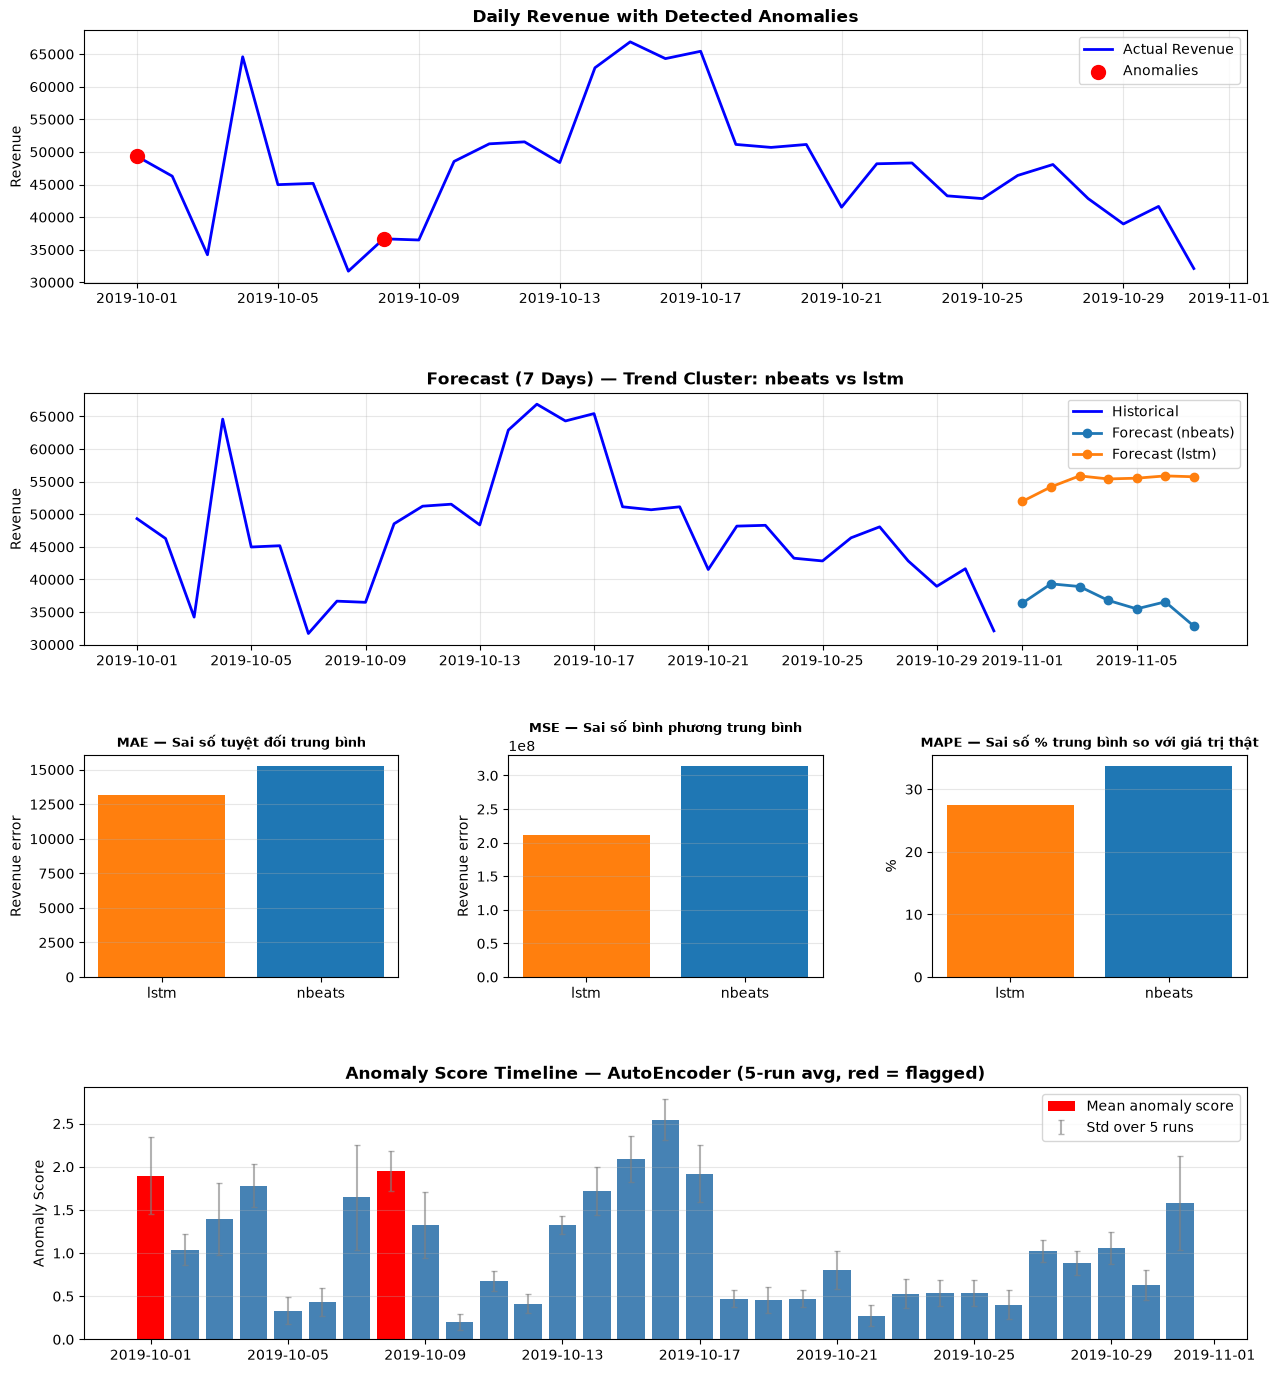

[OK] Plots displayed


In [10]:
if PLOT_RESULTS:
    from matplotlib.gridspec import GridSpec

    fig = plt.figure(figsize=(15, 17))
    gs = GridSpec(4, 3, figure=fig, height_ratios=[2.5, 2.5, 2.2, 2.5], hspace=0.45, wspace=0.35)

    # Biểu đồ 1: Doanh thu thực tế + ngày bị gắn cờ bất thường (cụm 2)
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(daily['date'], daily['revenue'], 'b-', linewidth=2, label='Actual Revenue')
    if len(anomalies) > 0:
        anom_dates = pd.to_datetime(anomalies['date'])
        anom_rev = anomalies['revenue']
        ax1.scatter(anom_dates, anom_rev, color='red', s=100, label='Anomalies', zorder=5)
    ax1.set_title('Daily Revenue with Detected Anomalies', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Revenue')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Biểu đồ 2: Lịch sử + dự báo nbeats vs lstm (cụm 1)
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(daily['date'], daily['revenue'], 'b-', linewidth=2, label='Historical')
    for model_name in set(predictions['model']):
        model_preds = predictions[predictions['model'] == model_name]
        ax2.plot(model_preds['forecast_date'], model_preds['predicted_revenue'], 'o-', linewidth=2, label=f'Forecast ({model_name})', markersize=6)
    ax2.set_title(f'Forecast ({FORECAST_HORIZON} Days) — Trend Cluster: nbeats vs lstm', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Revenue')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Biểu đồ 3: So sánh sai số backtest giữa nbeats và lstm -- MAE/MSE/MAPE,
    # mỗi chỉ số 1 subplot riêng (thang giá trị khác nhau nhiều bậc nên không
    # gộp chung 1 trục y). Mỗi subplot có tiêu đề kèm giải thích ngắn.
    metric_specs = [
        ('mae',  'MAE — Sai số tuyệt đối trung bình'),
        ('mse',  'MSE — Sai số bình phương trung bình'),
        ('mape', 'MAPE — Sai số % trung bình so với giá trị thật'),
    ]
    if not backtest_metrics.empty:
        colors = {'nbeats': 'tab:blue', 'lstm': 'tab:orange'}
        for col, (metric, title) in enumerate(metric_specs):
            axm = fig.add_subplot(gs[2, col])
            bar_colors = [colors.get(m, 'gray') for m in backtest_metrics['model']]
            axm.bar(backtest_metrics['model'], backtest_metrics[metric], color=bar_colors)
            axm.set_title(title, fontsize=9, fontweight='bold')
            axm.set_ylabel('%' if metric == 'mape' else 'Revenue error')
            axm.grid(True, alpha=0.3, axis='y')
            axm.tick_params(axis='x', rotation=0)

    # Biểu đồ 4 (riêng cụm anomaly/AutoEncoder): anomaly_score trung bình qua
    # N_STABILITY_RUNS lần chạy cho từng ngày; đỏ = bị gắn cờ, error bar = độ ổn định.
    # Cụm anomaly chỉ dùng 1 model (AutoEncoder) theo chủ ý -- không có biểu
    # đồ "so sánh model" ở đây, chỉ có 1 biểu đồ riêng thể hiện kết quả của nó.
    ax4 = fig.add_subplot(gs[3, :])
    eval_sorted = anomaly_eval.sort_values('date')
    bar_colors4 = ['red' if lbl == 1 else 'steelblue' for lbl in eval_sorted['anomaly_label']]
    ax4.bar(eval_sorted['date'], eval_sorted['mean_anomaly_score'], color=bar_colors4, width=0.8, label='Mean anomaly score')
    ax4.errorbar(eval_sorted['date'], eval_sorted['mean_anomaly_score'], yerr=eval_sorted['std_anomaly_score'],
                 fmt='none', ecolor='gray', alpha=0.6, capsize=2, label=f'Std over {N_STABILITY_RUNS} runs')
    ax4.set_title(f'Anomaly Score Timeline — AutoEncoder ({N_STABILITY_RUNS}-run avg, red = flagged)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Anomaly Score')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    plt.show()
    print("[OK] Plots displayed")

## Cell 9: Summary & Save Results

 In bảng tổng kết ra màn hình và lưu **toàn bộ** kết quả (config, data, backtest, forecast, anomalies) vào 1 file JSON (`data/logs/ml_notebook_results.json`) để log/xem lại lịch sử chạy. Cell này **chưa** ghi gì vào Postgres/Superset — việc đó nằm ở Cell 10.

In [11]:
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Data window:        {len(daily)} days ({daily['date'].min().date()} to {daily['date'].max().date()})")
folds_run = int(backtest_metrics['folds'].max()) if not backtest_metrics.empty else 0
print(f"Backtest:           rolling/walk-forward, {folds_run} fold(s) x {BACKTEST_HOLDOUT}-day test window")
print(f"Forecast horizon:   {FORECAST_HORIZON} days")
print(f"Anomalies detected: {len(anomalies)} / {len(daily)} ({len(anomalies)/len(daily)*100:.1f}%)")
print(f"Models:             {', '.join(predictor.model_names)}")
print(f"Anomaly backend:    {detector.backend} (stability check: {N_STABILITY_RUNS} runs)")
print("="*80)

# Lưu toàn bộ kết quả ra 1 file JSON để log/xem lại (không phải nơi Superset đọc dữ liệu)
if SAVE_JSON:
    results = {
        'timestamp': datetime.now(timezone.utc).isoformat(),
        'config': {
            'source': 'sample_data' if USE_SAMPLE_DATA else 'postgresql',
            'horizon': FORECAST_HORIZON,
            'data_points': len(daily),
            'n_epochs': N_EPOCHS,
            'n_splits_requested': N_SPLITS,
            'n_stability_runs': N_STABILITY_RUNS,
        },
        'data_summary': {
            'date_range': f"{daily['date'].min().date()} to {daily['date'].max().date()}",
            'revenue_stats': {
                'min': float(daily['revenue'].min()),
                'max': float(daily['revenue'].max()),
                'mean': float(daily['revenue'].mean()),
                'std': float(daily['revenue'].std()),
            },
        },
        'backtest': {
            'holdout_days_per_fold': BACKTEST_HOLDOUT,
            'folds_run': folds_run,
            'metrics': backtest_dict,
            'detail_per_fold': backtest_detail_dict,
        },
        'forecast': {
            'horizon_days': FORECAST_HORIZON,
            'predictions': forecast_dict,
        },
        'anomalies': {
            'backend': detector.backend,
            'contamination': CONTAMINATION,
            'flagged_days': len(anomalies),
            'flagged_rate_percent': len(anomalies) / len(daily) * 100,
            'anomalies': anomalies_dict[:10],
            'stability_runs': N_STABILITY_RUNS,
            'evaluation_all_days': anomaly_eval_dict,
        },
    }
    
    output_path = Path(OUTPUT_FILE)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(results, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
    print(f"\n[OK] Results saved: {OUTPUT_FILE}")
else:
    print("\n[SKIPPED] JSON save disabled")

print("\n[SUCCESS] ML Pipeline Complete!")


SUMMARY
Data window:        31 days (2019-10-01 to 2019-10-31)
Backtest:           rolling/walk-forward, 3 fold(s) x 6-day test window
Forecast horizon:   7 days
Anomalies detected: 2 / 31 (6.5%)
Models:             nbeats, lstm
Anomaly backend:    pyod_autoencoder (stability check: 5 runs)

[OK] Results saved: data/logs/ml_notebook_results.json

[SUCCESS] ML Pipeline Complete!


## Cell 10: Advanced — Run Real ML Job (Optional)

**WARNING**: This writes to PostgreSQL cache tables. Comment out unless you want to publish results to BI.

 Đây là cell **ghi dữ liệu thật** — publish `predictions` (Cell 6) và `anomalies` (Cell 7) vào 2 bảng Postgres `cache.predictions` / `cache.anomalies` (ghi đè theo kiểu truncate-and-insert, không cộng dồn lịch sử). Superset đọc trực tiếp 2 bảng này để vẽ dashboard "Batch ML - Forecast Comparison & Anomalies" — nên **chỉ sau khi chạy xong cell này**, kết quả mới hiển thị lên Superset.

In [12]:
from batch_layer.postgres_cache import PostgresCacheSync

print("[PUBLISHING TO BI CACHE]")
cache = PostgresCacheSync()

# Ghi đè (truncate + insert) cache.predictions bằng dự báo vừa tính ở Cell 6
cache.sync_predictions(predictions)
print(f"  [OK] Synced {len(predictions)} predictions to cache.predictions")

# Ghi đè cache.anomalies bằng các ngày bị gắn cờ ở Cell 7 (đổi 'date' -> 'event_date' cho khớp schema)
anomalies_out = scored[scored['anomaly_label'] == 1].rename(columns={'date': 'event_date'})
cache.sync_anomalies(anomalies_out)
print(f"  [OK] Synced {len(anomalies_out)} anomalies to cache.anomalies")

print("\n[SUCCESS] Results published to Superset BI")

[PUBLISHING TO BI CACHE]
  [OK] Synced 14 predictions to cache.predictions
  [OK] Synced 2 anomalies to cache.anomalies

[SUCCESS] Results published to Superset BI
